# Superstore Sales Analysis 🛒

## Project Overview
Analysis of US Superstore sales data (2014–2017).  
Dataset: 9,994 orders, 21 features.

**Key questions:**
- Which categories and regions are most profitable?
- How do discounts affect profit?
- What is the sales seasonality?

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample_Superstore.csv to Sample_Superstore (1).csv


## 1. Data Cleaning
Converting date columns and optimizing data types.

In [7]:
import pandas as pd

df = pd.read_csv("Sample_Superstore.csv", encoding="windows-1252")
#print(df.head())

#print(df.shape)
#print(df.columns.tolist())
#df.info()
#df.describe()

# 1. Конвертуємо дати з тексту в datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# 2. Конвертуємо категорійні колонки для економії пам'яті
cat_cols = ["Ship Mode", "Segment", "Country", "Region", "Category", "Sub-Category"]
df[cat_cols] = df[cat_cols].astype("category")

# 3. Перевіримо дублікати
print(df.duplicated().sum())

# 4. Додамо корисні колонки з дат — знадобляться для аналізу
df["Year"] = df["Order Date"].dt.year
df["month"] = df["Order Date"].dt.month

df.info()

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   category      
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   category      
 8   Country        9994 non-null   category      
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   category      
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   category      
 15  Sub-Category   9994

## 2. Sales & Profit by Category
Technology leads in profit despite fewer orders.
Furniture shows dangerously low margins.

In [8]:
# 1. Загальні показники бізнесу
print("Загальний дохід:", df["Sales"].sum().round(2))
print("Загальний прибуток:", df["Profit"].sum().round(2))
print("Середня маржа %:", (df["Profit"].sum() / df["Sales"].sum() * 100).round(2))

Загальний дохід: 2297200.86
Загальний прибуток: 286397.02
Середня маржа %: 12.47


In [9]:
# 2. Продажі і прибуток по категоріях
df.groupby("Category").agg(
    total_sales = ("Sales", "sum"),
    total_profit = ("Profit", "sum"),
    orders_count = ("Order ID", "count")
).round(2).sort_values("total_sales", ascending=False)


/tmp/ipykernel_9558/1807877980.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Category").agg(


,total_sales,total_profit,orders_count
Category,,,
Technology,836154.03,145454.95,1847
Furniture,741999.80,18451.27,2121
Office Supplies,719047.03,122490.80,6026


In [10]:
# 3. Топ-5 підкатегорій за прибутком
df.groupby("Sub-Category").agg(
    total_profit = ("Profit", "sum"),
    total_sales = ("Sales", "sum")
).round(2).sort_values("total_profit", ascending=False).head(5)

/tmp/ipykernel_9558/1958991644.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Sub-Category").agg(


,total_profit,total_sales
Sub-Category,,
Copiers,55617.82,149528.03
Phones,44515.73,330007.05
Accessories,41936.64,167380.32
Paper,34053.57,78479.21
Binders,30221.76,203412.73


In [11]:
# 4. Антитоп-5 — найзбитковіші підкатегорії
df.groupby("Sub-Category").agg(
    total_profit = ("Profit", "sum"),
    total_sales = ("Sales", "sum")
).round(2).sort_values("total_profit").head(5)

/tmp/ipykernel_9558/2470199817.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Sub-Category").agg(


,total_profit,total_sales
Sub-Category,,
Tables,-17725.48,206965.53
Bookcases,-3472.56,114880.00
Supplies,-1189.10,46673.54
Fasteners,949.52,3024.28
Machines,3384.76,189238.63


In [12]:
# 5. Продажі по регіонах
df.groupby("Region").agg(
    total_sales = ("Sales", "sum"),
    total_profit = ("Profit", "sum")
).round(2).sort_values("total_sales", ascending=False)

/tmp/ipykernel_9558/4283885393.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Region").agg(


,total_sales,total_profit
Region,,
West,725457.82,108418.45
East,678781.24,91522.78
Central,501239.89,39706.36
South,391721.90,46749.43


In [13]:
# 1. Продажі по роках
df.groupby("Year").agg(
    total_sales = ("Sales", "sum"),
    total_profit = ("Profit", "sum")
).round(2)

,total_sales,total_profit
Year,,
2014,484247.50,49543.97
2015,470532.51,61618.60
2016,609205.60,81795.17
2017,733215.26,93439.27


In [14]:
# 2. Динаміка по місяцях (всі роки разом)
df.groupby("month").agg(
    total_sales = ("Sales", "sum"),
    total_profit = ("Profit", "sum")
).round(2)

,total_sales,total_profit
month,,
1,94924.84,9134.45
2,59751.25,10294.61
3,205005.49,28594.69
4,137762.13,11587.44
5,155028.81,22411.31
6,152718.68,21285.80
7,147238.10,13832.66
8,159044.06,21776.94
9,307649.95,36857.48


In [15]:
# 3. Середня знижка по підкатегоріях — чому Tables збиткові?
df.groupby("Sub-Category").agg(
    avg_discount = ("Discount", "mean"),
    total_profit = ("Profit", "sum")
).round(3).sort_values("avg_discount", ascending=False).head(8)

/tmp/ipykernel_9558/21342661.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Sub-Category").agg(


,avg_discount,total_profit
Sub-Category,,
Binders,0.372,30221.763
Machines,0.306,3384.757
Tables,0.261,-17725.481
Bookcases,0.211,-3472.556
Chairs,0.170,26590.166
Appliances,0.167,18138.005
Copiers,0.162,55617.825
Phones,0.155,44515.731


In [16]:
# 4. Чи справді великі знижки = збиток?
# Розіб'ємо знижки на групи
df["discount_group"] = pd.cut(
    df["Discount"],
    bins=[-0.1, 0, 0.2, 0.4, 0.8],
    labels=["no discount", "low", "medium", "high"]
)

df.groupby("discount_group", observed=True).agg(
    avg_profit   = ("Profit", "mean"),
    total_profit = ("Profit", "sum"),
    orders_count = ("Order ID", "count")
).round(2)


,avg_profit,total_profit,orders_count
discount_group,,,
no discount,66.90,320987.60,4798
low,26.50,100785.47,3803
medium,-77.86,-35817.47,460
high,-106.71,-99558.59,933


In [17]:
# Фінальна перевірка — топ штатів за прибутком
df.groupby("State").agg(
    total_sales = ("Sales","sum"),
    total_profit = ("Profit", "sum")
).round(2).sort_values("total_profit", ascending=False).head(10)

,total_sales,total_profit
State,,
California,457687.63,76381.39
New York,310876.27,74038.55
Washington,138641.27,33402.65
Michigan,76269.61,24463.19
Virginia,70636.72,18597.95
Indiana,53555.36,18382.94
Georgia,49095.84,16250.04
Kentucky,36591.75,11199.70
Minnesota,29863.15,10823.19


In [18]:
# Антитоп — найзбитковіші штати
df.groupby("State").agg(
    total_sales = ("Sales","sum"),
    total_profit = ("Profit", "sum")
).round(2).sort_values("total_profit").head(10)


,total_sales,total_profit
State,,
Texas,170188.05,-25729.36
Ohio,78258.14,-16971.38
Pennsylvania,116511.91,-15559.96
Illinois,80166.10,-12607.89
North Carolina,55603.16,-7490.91
Colorado,32108.12,-6527.86
Tennessee,30661.87,-5341.69
Arizona,35282.00,-3427.92
Florida,89473.71,-3399.30


## 3. Key Findings
- 📈 Revenue grew from $484K (2014) to $733K (2017)
- 🔴 Discounts above 20% generate losses averaging -$78 per order
- 🌍 Texas alone loses -$25K despite $170K in sales

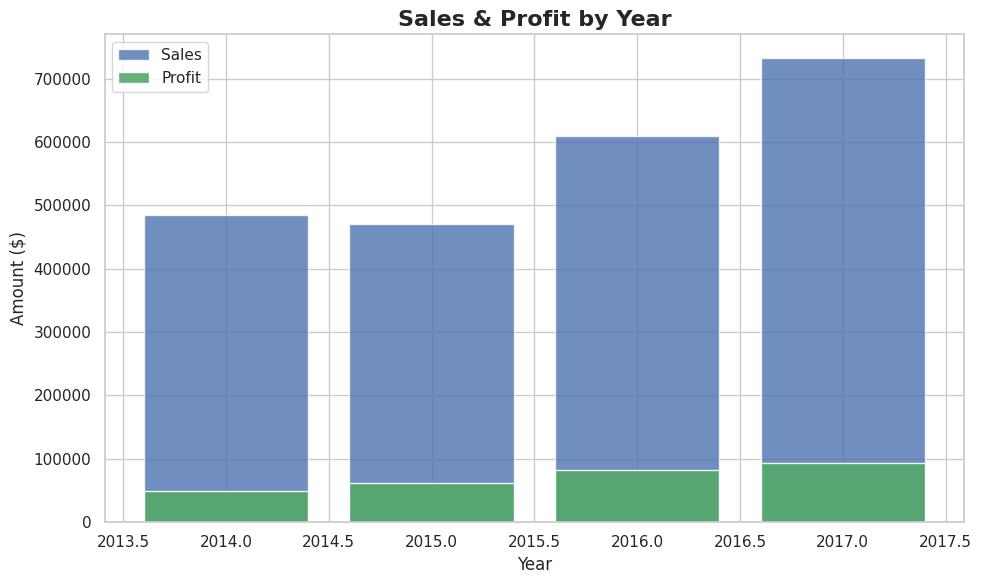

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Базові налаштування для красивих графіків
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

#Графік 1
yearly = df.groupby("Year").agg(
    total_sales  = ("Sales", "sum"),
    total_profit = ("Profit", "sum")
).round(2).reset_index()

fig, ax = plt.subplots()

ax.bar(yearly["Year"], yearly["total_sales"],
       label="Sales", color="#4C72B0", alpha=0.8)
ax.bar(yearly["Year"], yearly["total_profit"],
       label="Profit", color="#55A868", alpha=0.9)

ax.set_title("Sales & Profit by Year", fontsize=16, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Amount ($)")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_9558/1278261626.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_profit = df.groupby("Category")["Profit"].sum().round(2).reset_index()


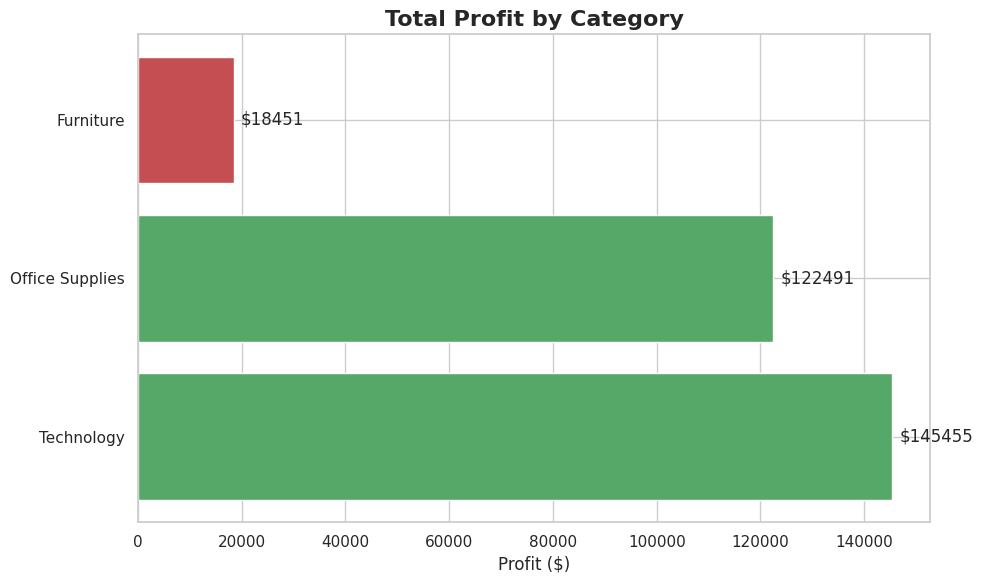

In [20]:
# Графік 2 - Прибуток по категоріях
cat_profit = df.groupby("Category")["Profit"].sum().round(2).reset_index()
cat_profit = cat_profit.sort_values("Profit", ascending=False)

fig, ax = plt.subplots()

bars = ax.barh(cat_profit["Category"], cat_profit["Profit"],
               color=["#55A868", "#55A868", "#C44E52"])
ax.set_title("Total Profit by Category", fontsize=16, fontweight="bold")
ax.set_xlabel("Profit ($)")
ax.bar_label(bars, fmt="$%.0f", padding=5)

plt.tight_layout()
plt.show()

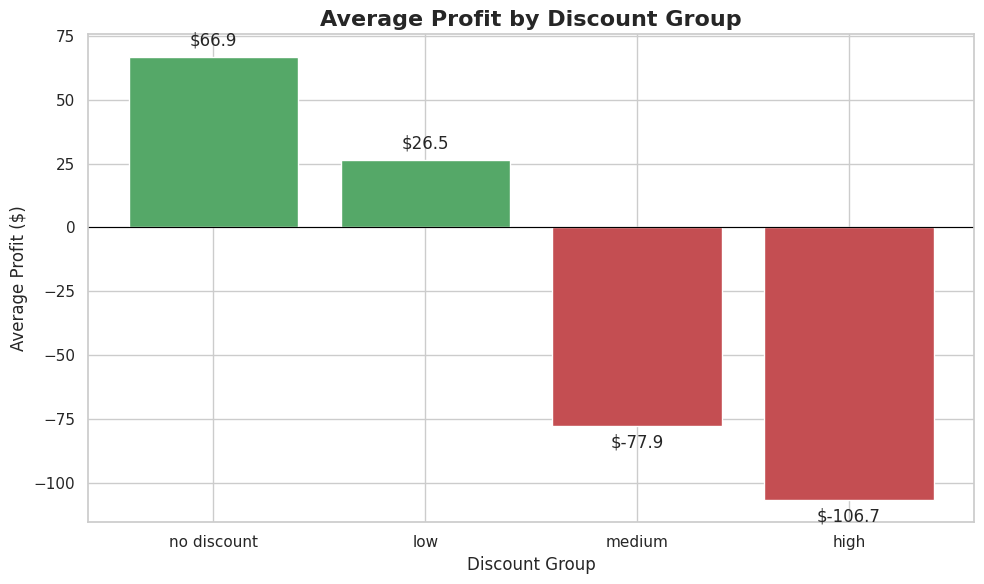

In [21]:
# Графік 3 — Вплив знижок на прибуток
discount_data = df.groupby("discount_group", observed=True).agg(
    avg_profit = ("Profit", "mean")
).round(2).reset_index()

colors = ["#55A868", "#55A868", "#C44E52", "#C44E52"]

fig, ax = plt.subplots()

bars = ax.bar(discount_data["discount_group"],
              discount_data["avg_profit"],
              color=colors)

ax.axhline(y=0, color="black", linewidth=0.8)  # лінія нуля
ax.set_title("Average Profit by Discount Group", fontsize=16, fontweight="bold")
ax.set_xlabel("Discount Group")
ax.set_ylabel("Average Profit ($)")
ax.bar_label(bars, fmt="$%.1f", padding=5)

plt.tight_layout()
plt.show()

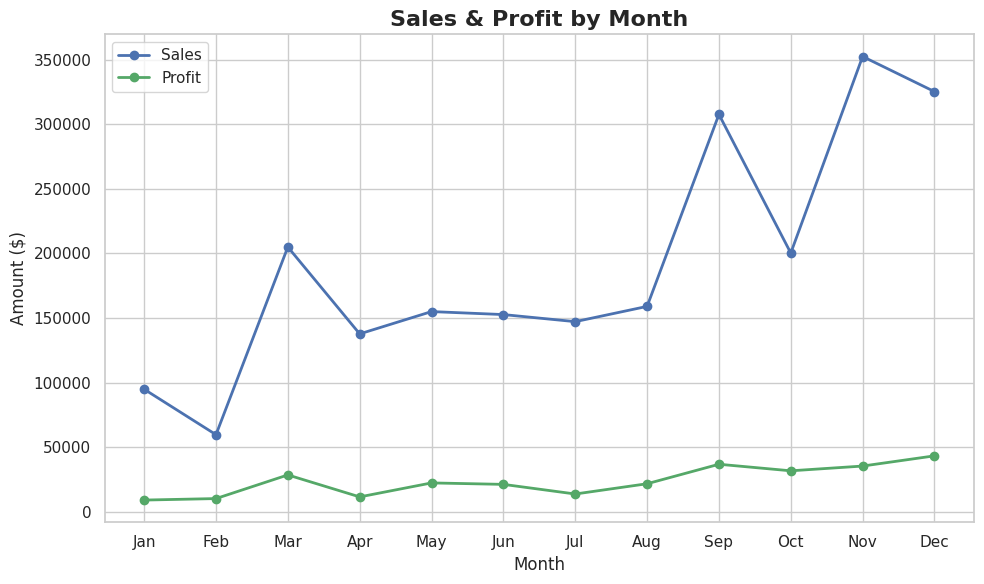

In [22]:
# Графік 4 — Сезонність продажів

monthly = df.groupby("month").agg(
    total_sales  = ("Sales", "sum"),
    total_profit = ("Profit", "sum")
).round(2).reset_index()

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots()

ax.plot(monthly["month"], monthly["total_sales"],
        marker="o", color="#4C72B0", label="Sales", linewidth=2)
ax.plot(monthly["month"], monthly["total_profit"],
        marker="o", color="#55A868", label="Profit", linewidth=2)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title("Sales & Profit by Month", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Amount ($)")
ax.legend()

plt.tight_layout()
plt.show()

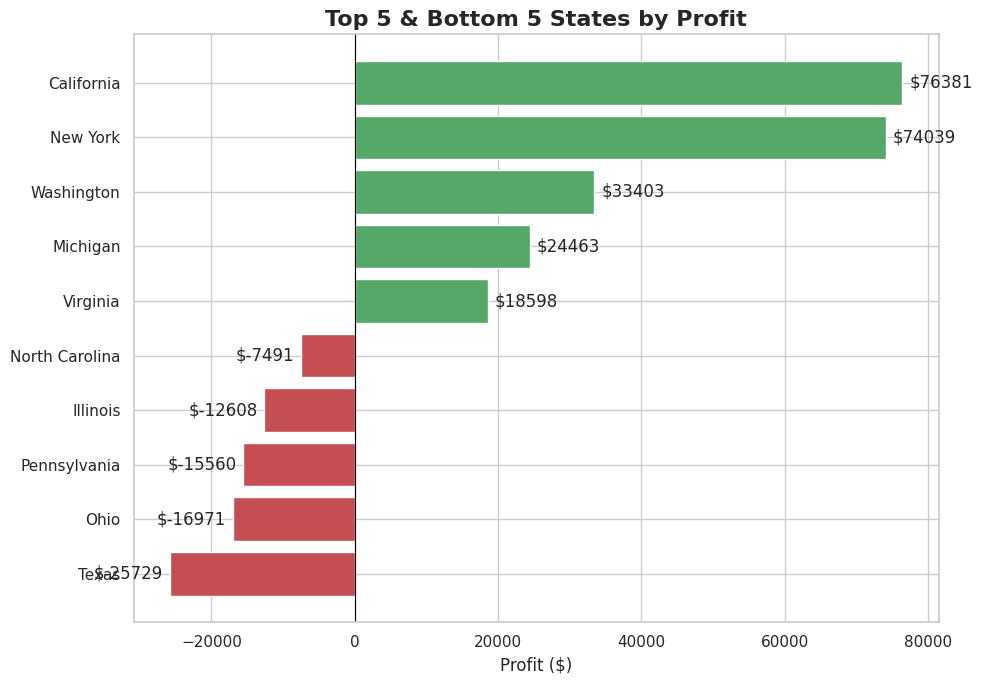

In [23]:
# Топ-5 і антитоп-5 штатів разом
state_profit = df.groupby("State")["Profit"].sum().round(2).reset_index()

top5    = state_profit.nlargest(5, "Profit")
bottom5 = state_profit.nsmallest(5, "Profit")
combined = pd.concat([top5, bottom5]).sort_values("Profit")

colors = ["#C44E52" if x < 0 else "#55A868" for x in combined["Profit"]]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(combined["State"], combined["Profit"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Top 5 & Bottom 5 States by Profit", fontsize=16, fontweight="bold")
ax.set_xlabel("Profit ($)")
ax.bar_label(bars, fmt="$%.0f", padding=5)

plt.tight_layout()
plt.show()